# Decision Tree Classifier Practical Implementation

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [31]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [32]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [33]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [34]:
# fig, axes = plt.Subplots(2,2, figsize(8,6))


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

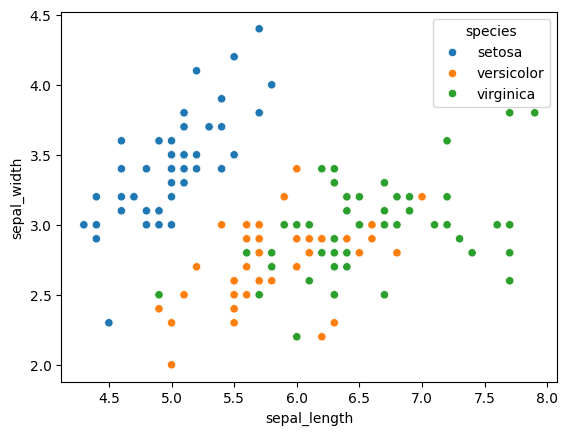

In [35]:

sns.scatterplot(x = df['sepal_length'], y = df['sepal_width'], hue=df['species'])

In [36]:
from sklearn.datasets import load_iris
iris = load_iris()

In [37]:
y = iris['target']
X = df.drop('species', axis=1)

In [38]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [40]:
## Apply decision tree classifier

from sklearn.tree import DecisionTreeClassifier
treeclsi = DecisionTreeClassifier()

In [41]:
treeclsi.fit(X_train, y_train)

DecisionTreeClassifier()

[Text(0.3181818181818182, 0.9285714285714286, 'x[3] <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.22727272727272727, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.2727272727272727, 0.8571428571428572, 'True  '),
 Text(0.4090909090909091, 0.7857142857142857, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.36363636363636365, 0.8571428571428572, '  False'),
 Text(0.18181818181818182, 0.6428571428571429, 'x[3] <= 1.65\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.09090909090909091, 0.5, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]'),
 Text(0.2727272727272727, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6363636363636364, 0.6428571428571429, 'x[3] <= 1.75\ngini = 0.159\nsamples = 46\nvalue = [0, 4, 42]'),
 Text(0.45454545454545453, 0.5, 'x[2] <= 5.35\ngini = 0.49\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.36363636363636365, 0.35714285714285715, 'x[0] <= 6.5\ngini = 0.48\nsamples = 5\

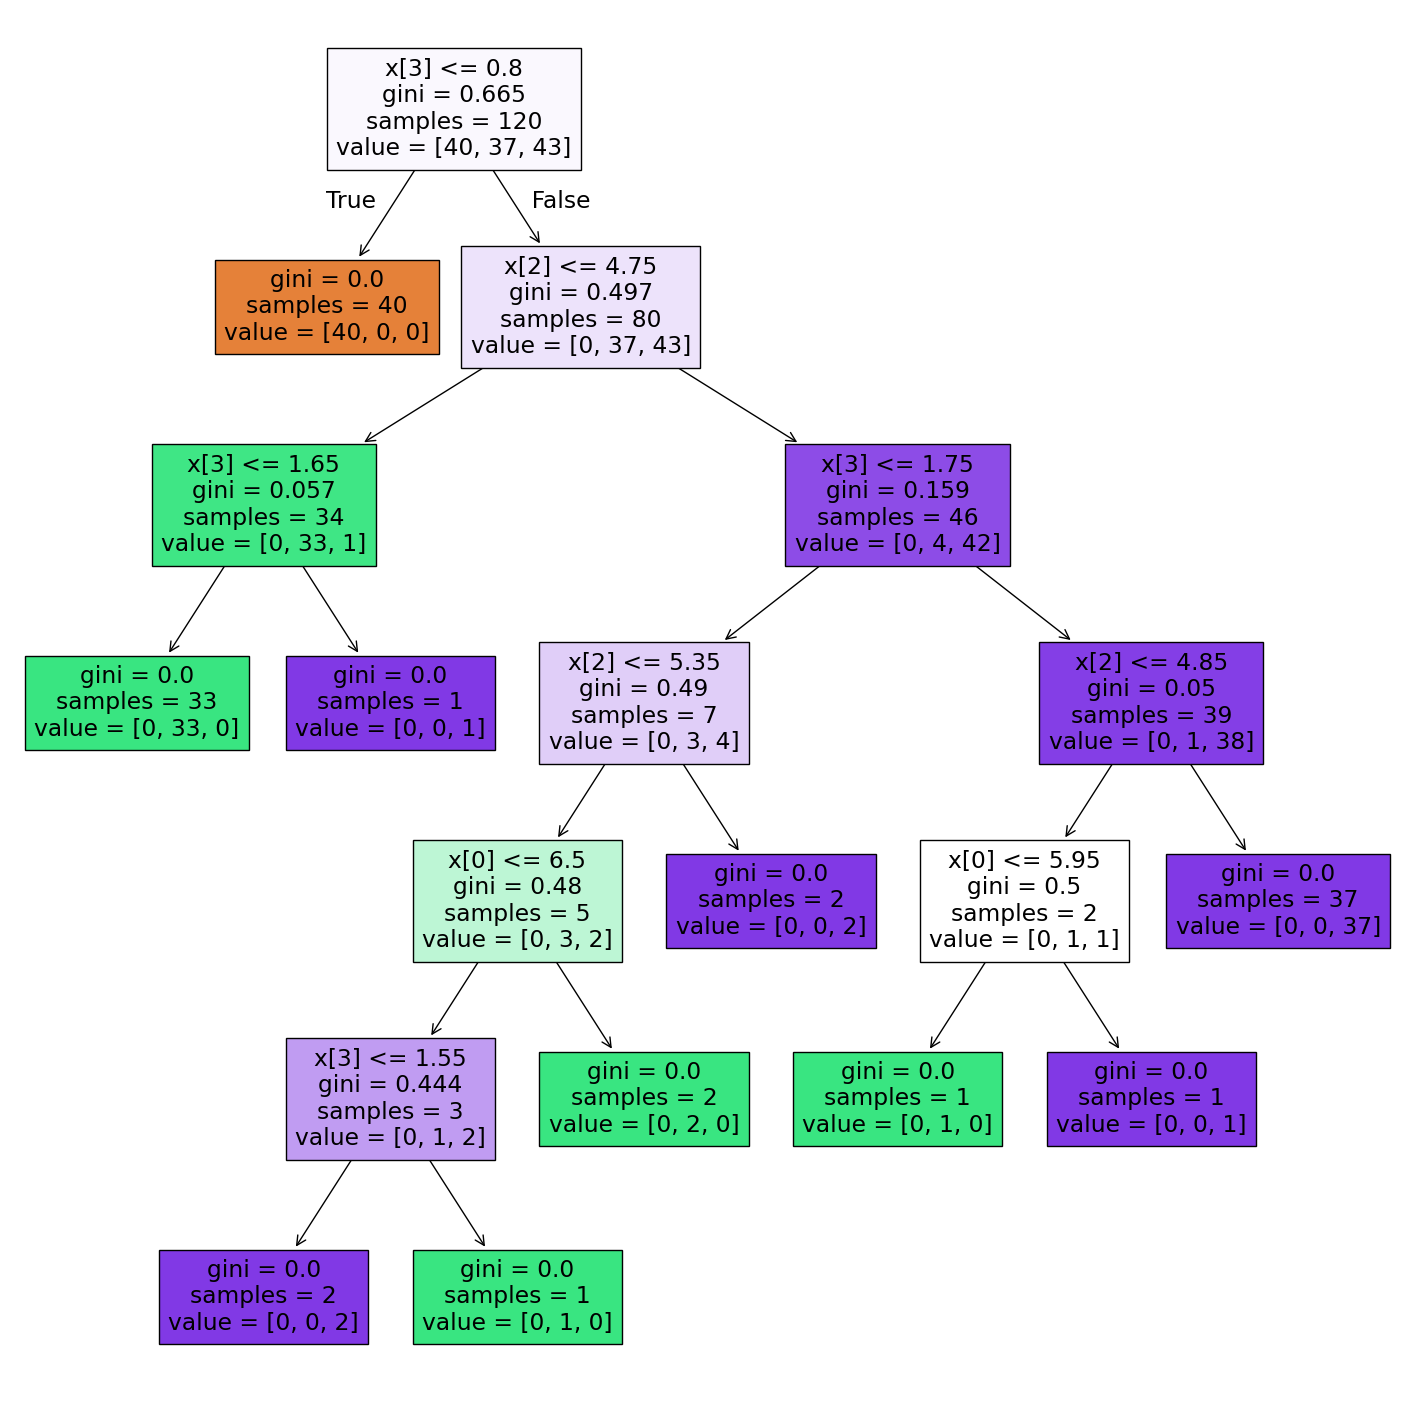

In [42]:
from sklearn import tree
plt.figure(figsize=(18,18))
tree.plot_tree(treeclsi, filled=True)

Post pruning to prevent the overfiting so we use the max_depth and other to prune the tree to reducing the depth of the tree

In [43]:
model = DecisionTreeClassifier(max_depth=2)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [40, 37, 43]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.75\ngini = 0.497\nsamples = 80\nvalue = [0, 37, 43]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.057\nsamples = 34\nvalue = [0, 33, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.159\nsamples = 46\nvalue = [0, 4, 42]')]

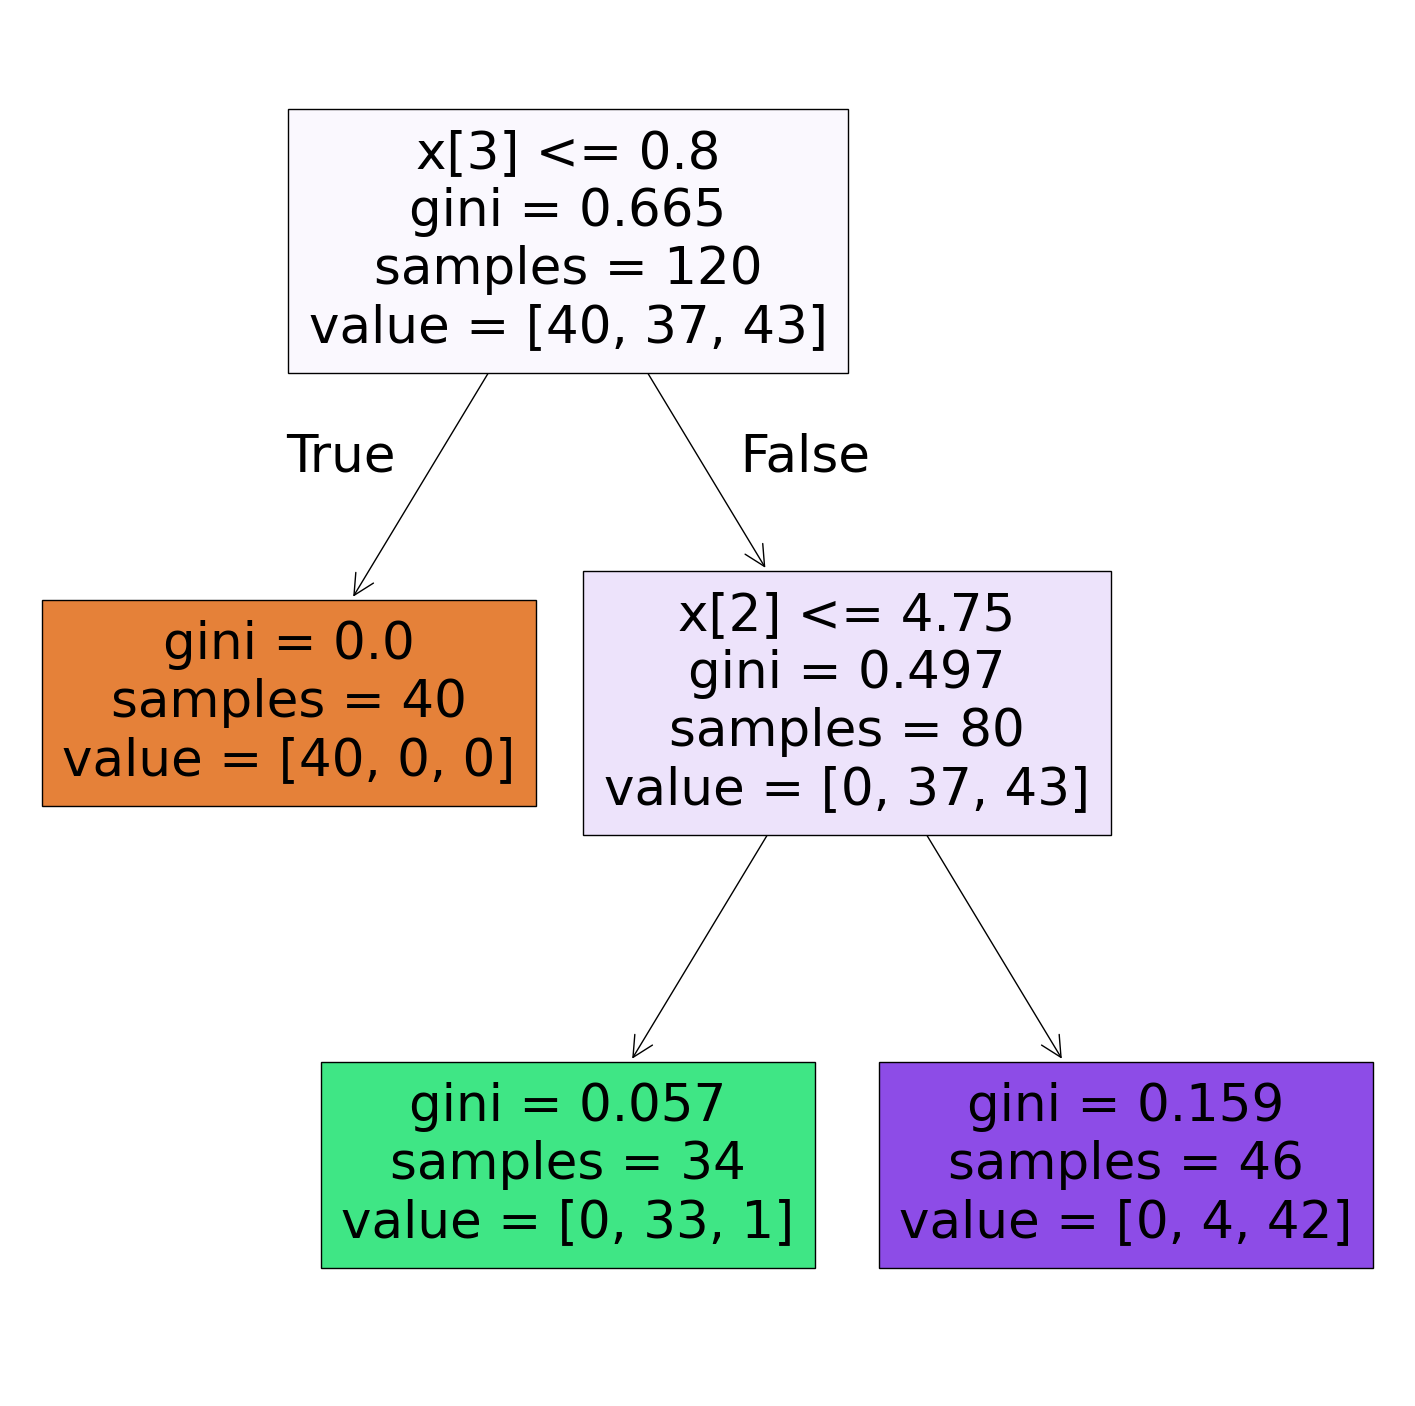

In [44]:
plt.figure(figsize=(18,18))
tree.plot_tree(model, filled=True)

here you can see that it is going to only the depth of 2

In [45]:
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'Confusion Matrix')

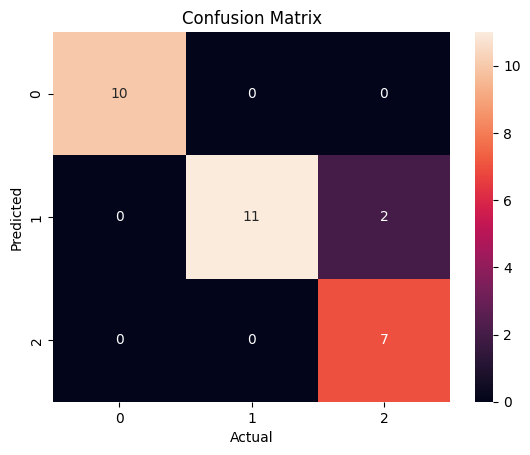

In [46]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')

In [47]:
print(accuracy_score(y_test, y_pred))

0.9333333333333333


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.85      0.92        13
           2       0.78      1.00      0.88         7

    accuracy                           0.93        30
   macro avg       0.93      0.95      0.93        30
weighted avg       0.95      0.93      0.93        30



# Decision Tree Classifier Prepruning And Hyperparameter Tuning

In [20]:
params = {
        'criterion':['gini', 'entropy', 'log_loss'],
        'splitter':['best', 'random'],
        'max_depth':[1,2,3,4,5,6,7,8],
        'min_samples_split':[1,2,3],
        'min_samples_leaf':[1,2,3],
        'max_features':['auto', 'sqrt', 'log2']
}

In [21]:
params

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 6, 7, 8],
 'min_samples_split': [1, 2, 3],
 'min_samples_leaf': [1, 2, 3],
 'max_features': ['auto', 'sqrt', 'log2']}

In [22]:
from sklearn.model_selection import GridSearchCV

tree_model = DecisionTreeClassifier()

grid = GridSearchCV(estimator=tree_model, param_grid=params, cv=5, scoring='accuracy')

In [23]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [1, 2, 3],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [24]:
grid.best_estimator_

DecisionTreeClassifier(max_depth=6, max_features='log2', min_samples_leaf=2,
                       splitter='random')

In [25]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 6,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'splitter': 'random'}

In [26]:
grid.best_score_

0.975

In [27]:
y_pred = grid.predict(X_test)

<Axes: >

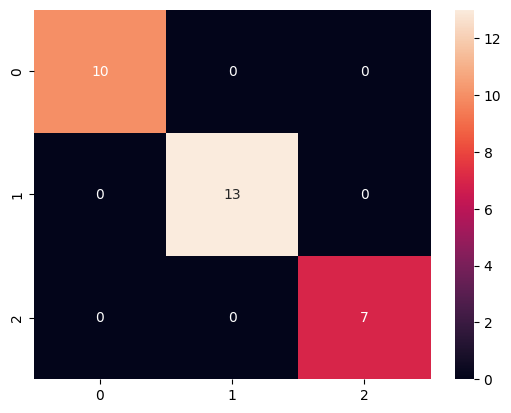

In [28]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

In [29]:
print(accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

